## Import necessary library


In [191]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import os
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
from torch import nn
from torch.utils.data import DataLoader

## Get File path and load the csv data


In [192]:
from util.data_path import soybean_price_avg_year_fix as data_file

In [193]:
wide = pd.read_csv(data_file)
long = wide.melt(id_vars="year", var_name="month", value_name="price").sort_values(
    ["year", "month"]
)

long["date"] = pd.to_datetime(
    (long["year"]).astype(str) + "-" + long["month"].astype(str).str.zfill(2) + "-01"
)
long = long.set_index("date").sort_index()

## Set the training dataset and the predicted data

**Training Period**: Using the last 5 years of data (2019-2023) for improved model performance

- Training: 2562-2566 (Buddhist calendar) / 2019-2023 (Gregorian calendar)
- Prediction: 2567 (Buddhist calendar) / 2024 (Gregorian calendar)


In [194]:
gregorian_start = 2019  # Start of 5-year training period
gregorian_end = 2023  # End of 5-year training period
gregorian_pred = 2024  # Prediction year

train = long[(long.index.year >= gregorian_start) & (long.index.year <= gregorian_end)][
    "price"
].to_frame()
future = long[long.index.year == gregorian_pred]["price"].to_frame()

scaler = MinMaxScaler()
train["scaled"] = scaler.fit_transform(train[["price"]])

series = train["scaled"].values.astype(np.float32)

# LSTM Model And Predict Graph


## Create a sequence dataset class for LSTM prediction


In [195]:
from util.lstm_cust_class import SeqDataset
from util.lstm_cust_class import LSTMRegressor

SEQ_LEN = 12
PRED_LEN = 12

In [196]:
ds = SeqDataset(series, SEQ_LEN, PRED_LEN)
loader = DataLoader(ds, batch_size=len(ds))

## Training the LSTM model


In [197]:
model = LSTMRegressor()
crit = nn.MSELoss()
opt = torch.optim.Adam(model.parameters(), lr=1e-2)

EPOCHS = 300
for epoch in range(1, EPOCHS + 1):
    for seq, targ in loader:
        opt.zero_grad()
        pred = model(seq)
        loss = crit(pred.squeeze(), targ[:, 0])
        loss.backward()
        opt.step()
    if epoch % 50 == 0:
        print(f"epoch {epoch:>3}/{EPOCHS}  loss={loss.item():.5f}")

epoch  50/300  loss=0.01740
epoch 100/300  loss=0.00824
epoch 150/300  loss=0.00753
epoch 200/300  loss=0.00731
epoch 250/300  loss=0.00556
epoch 300/300  loss=0.00592


## Predict the data for the next year


In [198]:
model.eval()
with torch.no_grad():
    window = torch.from_numpy(series[-SEQ_LEN:]).unsqueeze(0).unsqueeze(-1)
    preds = []
    for _ in range(PRED_LEN):
        nxt = model(window)
        preds.append(nxt.item())
        window = torch.cat([window[:, 1:, :], nxt.unsqueeze(0)], dim=1)

preds = scaler.inverse_transform(np.array(preds).reshape(-1, 1)).flatten()

gregorian_year = 2024
forecast = pd.Series(
    preds,
    index=pd.date_range(f"{gregorian_year}-01-01", periods=12, freq="MS"),
    name="forecast_price",
)

print("--- Forecast for 2567 ---")
print(forecast.round(2))

--- Forecast for 2567 ---
2024-01-01    26.78
2024-02-01    27.08
2024-03-01    27.61
2024-04-01    28.19
2024-05-01    28.74
2024-06-01    29.20
2024-07-01    29.57
2024-08-01    29.85
2024-09-01    30.19
2024-10-01    30.42
2024-11-01    30.44
2024-12-01    30.22
Freq: MS, Name: forecast_price, dtype: float64


In [199]:
cmp = pd.concat([future["price"].rename("actual"), forecast], axis=1)
print("\n--- Actual vs Forecast (debug view) ---")
print(cmp.round(2))


--- Actual vs Forecast (debug view) ---
            actual  forecast_price
2024-01-01   19.45           26.78
2024-02-01   19.45           27.08
2024-03-01   19.45           27.61
2024-04-01   21.67           28.19
2024-05-01   19.78           28.74
2024-06-01   17.50           29.20
2024-07-01   17.38           29.57
2024-08-01   17.25           29.85
2024-09-01   17.13           30.19
2024-10-01   17.00           30.42
2024-11-01   17.00           30.44
2024-12-01   17.10           30.22


## Save the Forecasted Price LSTM Model


In [200]:
from util.data_path import LSTM_5T_for
from datetime import datetime

In [201]:
# Verify training data period and size
print(f"Training data shape: {train.shape}")
print(f"Training data period: {train.index.min()} to {train.index.max()}")
print(
    f"Training data years: {train.index.year.min()} to {train.index.year.max()} (Gregorian)"
)
print(f"Total training samples: {len(train)} months ({len(train) / 12:.1f} years)")

Training data shape: (60, 2)
Training data period: 2019-01-01 00:00:00 to 2023-12-01 00:00:00
Training data years: 2019 to 2023 (Gregorian)
Total training samples: 60 months (5.0 years)


In [202]:
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
filename = f"{data_file.parent.name}_forecast.txt"
filepath = LSTM_5T_for / filename

# Save forecast data to text file
with open(filepath, "w") as f:
    f.write(f"LSTM Forecast Results for Soybean Prices (2024) {timestamp}\n")
    f.write("=" * 50 + "\n\n")
    f.write("Forecast Data:\n")
    f.write("-" * 20 + "\n")
    for date, price in forecast.items():
        f.write(f"{date.strftime('%Y-%m-%d')}: {price:.2f}\n")

    f.write("\nOverall Statistics:\n")
    f.write("-" * 20 + "\n")
    f.write(f"Mean Forecast Price: {forecast.mean():.2f}\n")
    f.write(f"Min Forecast Price: {forecast.min():.2f}\n")
    f.write(f"Max Forecast Price: {forecast.max():.2f}\n")
    f.write(f"Standard Deviation: {forecast.std():.2f}\n")

print(f"Forecast prices saved to: {filepath}")
print(f"File size: {os.path.getsize(filepath)} bytes")

Forecast prices saved to: c:\Users\thatt\Documents\Coding Project\Science Projects\AI Crop Land-Used\model\forecast_price\LSTM-5T\soybean_forecast.txt
File size: 538 bytes


## Compare The Error of a predicted data in a table format


In [203]:
error = cmp["actual"] - cmp["forecast_price"]
abs_error = abs(error)
# Calculate absolute percentage error
abs_pct_error = abs_error / cmp["actual"] * 100
mae_lstm = mean_absolute_error(cmp["actual"], cmp["forecast_price"])
mape_lstm = abs_pct_error.mean()  # Mean Absolute Percentage Error

print("\n--- Monthly Errors ---")
error_df = pd.DataFrame(
    {
        "actual": cmp["actual"],
        "forecast": cmp["forecast_price"],
        "error": error,
        "abs_error": abs_error,
        "abs_pct_error": abs_pct_error,  # Add percentage error to the dataframe
    }
)
print(error_df.round(4))
print(f"\nOverall Mean Absolute Error: {mae_lstm:.6f}")
print(f"Overall Mean Absolute Percentage Error: {mape_lstm:.4f}%")
print(f"LSTM Accuracy = {100 - (mae_lstm / cmp['actual'].mean() * 100):.2f}%")


--- Monthly Errors ---
            actual  forecast    error  abs_error  abs_pct_error
2024-01-01   19.45   26.7796  -7.3296     7.3296        37.6841
2024-02-01   19.45   27.0820  -7.6320     7.6320        39.2392
2024-03-01   19.45   27.6066  -8.1566     8.1566        41.9363
2024-04-01   21.67   28.1919  -6.5219     6.5219        30.0962
2024-05-01   19.78   28.7369  -8.9569     8.9569        45.2826
2024-06-01   17.50   29.1979 -11.6979    11.6979        66.8454
2024-07-01   17.38   29.5683 -12.1883    12.1883        70.1284
2024-08-01   17.25   29.8538 -12.6038    12.6038        73.0656
2024-09-01   17.13   30.1942 -13.0642    13.0642        76.2648
2024-10-01   17.00   30.4167 -13.4167    13.4167        78.9218
2024-11-01   17.00   30.4398 -13.4398    13.4398        79.0576
2024-12-01   17.10   30.2161 -13.1161    13.1161        76.7022

Overall Mean Absolute Error: 10.676980
Overall Mean Absolute Percentage Error: 59.6020%
LSTM Accuracy = 41.80%


## Plot The predicted data compare to an actual data


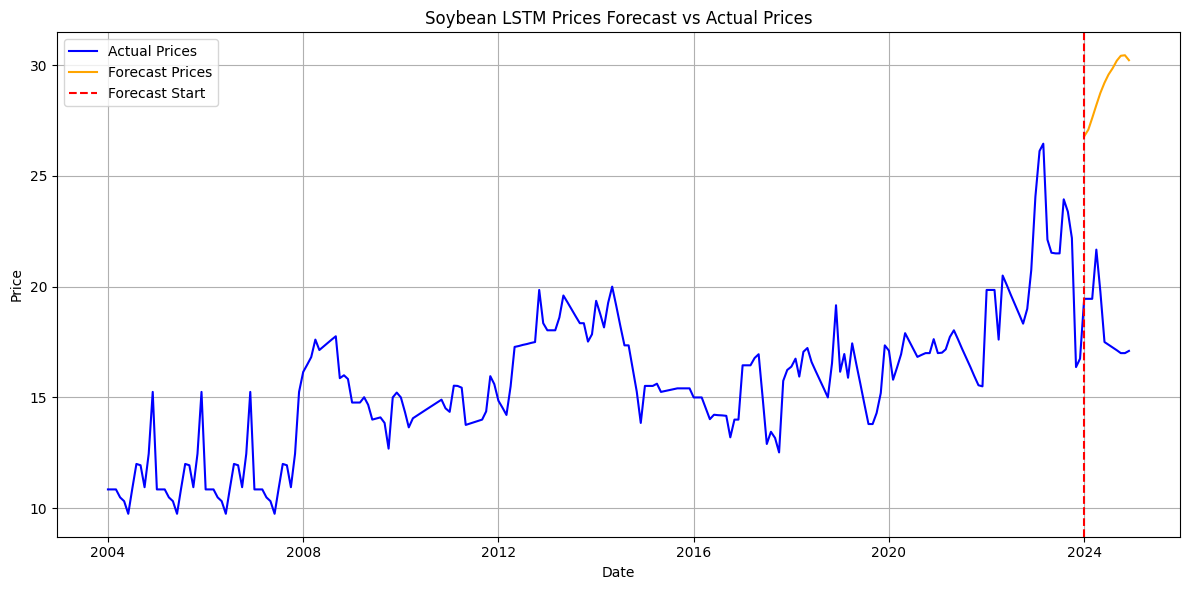

In [204]:
plt.figure(figsize=(12, 6))
plt.plot(long.index, long["price"], label="Actual Prices", color="blue")
plt.plot(forecast.index, forecast, label="Forecast Prices", color="orange")
plt.axvline(
    x=pd.Timestamp(f"{gregorian_year}-01-01"),
    color="red",
    linestyle="--",
    label="Forecast Start",
)
plt.title(f"{data_file.parent.name.capitalize()} LSTM Prices Forecast vs Actual Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# Transformer Model And Error Graph


## PLot the Error Analysis graph


<Figure size 1400x800 with 0 Axes>

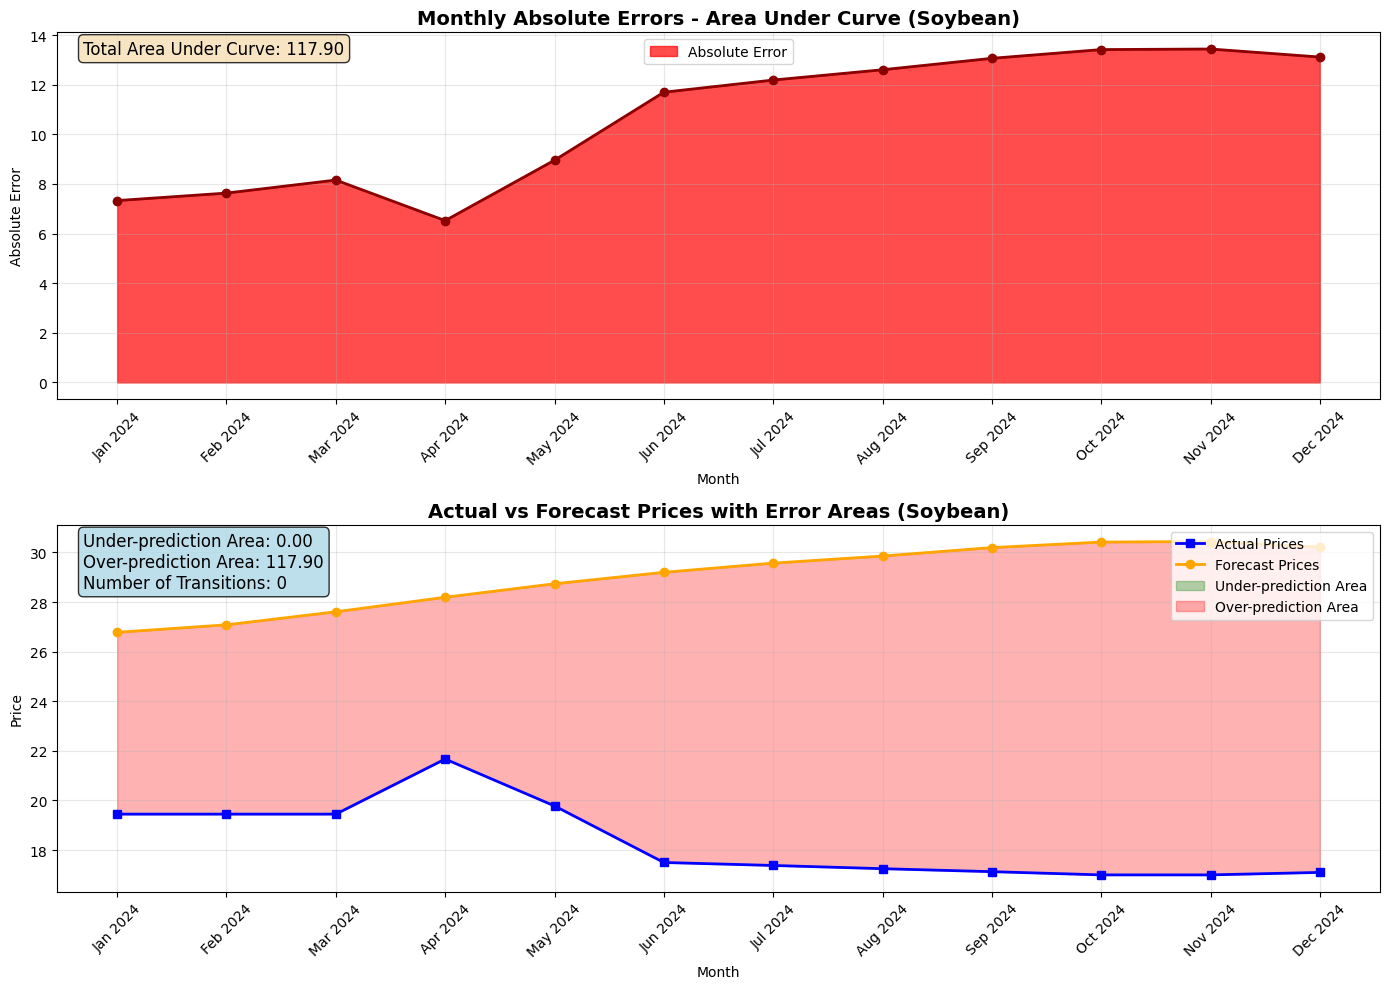

In [205]:
# Create area plot to visualize monthly errors
plt.figure(figsize=(14, 8))

# Calculate error values (in case this cell is run before the error calculation cell)
error = cmp["actual"] - cmp["forecast_price"]
abs_error = abs(error)

# Add the error columns to the cmp DataFrame if they don't exist
if "error" not in cmp.columns:
    cmp["error"] = error
if "abs_error" not in cmp.columns:
    cmp["abs_error"] = abs_error

# Create month labels for better readability
month_labels = [date.strftime("%b %Y") for date in cmp.index]

# Create subplots for different error visualizations
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Area plot of absolute errors
ax1.fill_between(
    range(len(cmp)), cmp["abs_error"], alpha=0.7, color="red", label="Absolute Error"
)
ax1.plot(range(len(cmp)), cmp["abs_error"], color="darkred", linewidth=2, marker="o")
ax1.set_title(
    f"Monthly Absolute Errors - Area Under Curve ({data_file.parent.name.capitalize()})",
    fontsize=14,
    fontweight="bold",
)
ax1.set_xlabel("Month")
ax1.set_ylabel("Absolute Error")
ax1.set_xticks(range(len(cmp)))
ax1.set_xticklabels(month_labels, rotation=45)
ax1.grid(True, alpha=0.3)
ax1.legend()

# Add area calculation text
total_area = np.trapezoid(cmp["abs_error"])
ax1.text(
    0.02,
    0.98,
    f"Total Area Under Curve: {total_area:.2f}",
    transform=ax1.transAxes,
    fontsize=12,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8),
)

# Plot 2: Comparison of actual vs forecast with error areas
ax2.plot(
    range(len(cmp)),
    cmp["actual"],
    label="Actual Prices",
    color="blue",
    linewidth=2,
    marker="s",
)
ax2.plot(
    range(len(cmp)),
    cmp["forecast_price"],
    label="Forecast Prices",
    color="orange",
    linewidth=2,
    marker="o",
)

# Find intersection points between actual and forecast
intersect_indices = []
for i in range(1, len(cmp)):
    # Check if actual and forecast cross between i-1 and i
    prev_diff = cmp["actual"].iloc[i - 1] - cmp["forecast_price"].iloc[i - 1]
    curr_diff = cmp["actual"].iloc[i] - cmp["forecast_price"].iloc[i]

    if (prev_diff * curr_diff <= 0) and (
        prev_diff != 0 or curr_diff != 0
    ):  # Sign change or one is zero
        # Linear interpolation to find exact intersection point
        if prev_diff == curr_diff:  # They're equal (both 0)
            t = 0  # At point i-1
        else:
            t = abs(prev_diff) / (abs(prev_diff) + abs(curr_diff))

        intersect_x = (i - 1) + t
        intersect_y = cmp["actual"].iloc[i - 1] + t * (
            cmp["actual"].iloc[i] - cmp["actual"].iloc[i - 1]
        )

        intersect_indices.append((intersect_x, intersect_y))

# Fill areas between actual and forecast to show errors
ax2.fill_between(
    range(len(cmp)),
    cmp["actual"],
    cmp["forecast_price"],
    where=(cmp["actual"] >= cmp["forecast_price"]),
    color="green",
    alpha=0.3,
    label="Under-prediction Area",
    interpolate=True,
)
ax2.fill_between(
    range(len(cmp)),
    cmp["actual"],
    cmp["forecast_price"],
    where=(cmp["actual"] < cmp["forecast_price"]),
    color="red",
    alpha=0.3,
    label="Over-prediction Area",
    interpolate=True,
)

# Mark intersection points with vertical lines and markers
for idx, (x, y) in enumerate(intersect_indices):
    ax2.axvline(x, color="purple", linestyle="--", alpha=0.7, linewidth=1.5)
    ax2.plot(
        x,
        y,
        "o",
        color="purple",
        markersize=8,
        label="Intersection Point" if idx == 0 else "",
    )
    ax2.text(
        x,
        y * 1.05,
        f"Transition\n({month_labels[int(x)][:3]})",
        ha="center",
        color="purple",
        fontweight="bold",
        bbox=dict(facecolor="white", alpha=0.7, boxstyle="round,pad=0.3"),
    )

ax2.set_title(
    f"Actual vs Forecast Prices with Error Areas ({data_file.parent.name.capitalize()})",
    fontsize=14,
    fontweight="bold",
)
ax2.set_xlabel("Month")
ax2.set_ylabel("Price")
ax2.set_xticks(range(len(cmp)))
ax2.set_xticklabels(month_labels, rotation=45)
ax2.grid(True, alpha=0.3)
ax2.legend(loc="upper right")

# Calculate and display area statistics
under_pred_area = np.trapezoid(np.maximum(cmp["actual"] - cmp["forecast_price"], 0))
over_pred_area = np.trapezoid(np.maximum(cmp["forecast_price"] - cmp["actual"], 0))

# Count number of transitions
num_transitions = len(intersect_indices)

# Create statistics text
stats_text = (
    f"Under-prediction Area: {under_pred_area:.2f}\n"
    f"Over-prediction Area: {over_pred_area:.2f}\n"
    f"Number of Transitions: {num_transitions}"
)

ax2.text(
    0.02,
    0.98,
    stats_text,
    transform=ax2.transAxes,
    fontsize=12,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="lightblue", alpha=0.8),
)

plt.tight_layout()
plt.show()

## Analyze The Error of a predicted data


In [206]:
print("\n--- Area Under Curve Analysis ---")
print(f"Total Absolute Error Area: {total_area:.4f}")
print(f"Under-prediction Area: {under_pred_area:.4f}")
print(f"Over-prediction Area: {over_pred_area:.4f}")
print(f"Net Error Area: {under_pred_area - over_pred_area:.4f}")
print(f"Average Monthly Absolute Error: {total_area / len(cmp):.4f}")
print(f"Number of Transition Points: {len(intersect_indices)}")

# Monthly breakdown
print("\n--- Monthly Error Areas ---")
for i, (date, row) in enumerate(cmp.iterrows()):
    month_label = date.strftime("%b %Y")
    error_type = (
        "Under-prediction"
        if row["actual"] > row["forecast_price"]
        else "Over-prediction"
        if row["actual"] < row["forecast_price"]
        else "Exact Match"
    )
    print(f"{month_label}: Abs Error = {row['abs_error']:.4f} ({error_type})")

# Transition analysis
if intersect_indices:
    print("\n--- Transition Points ---")
    for idx, (x, y) in enumerate(intersect_indices):
        transition_month = month_labels[int(x)]
        next_month = month_labels[min(int(x) + 1, len(month_labels) - 1)]
        print(
            f"Transition {idx + 1}: Between {transition_month} and {next_month} at position {x:.2f}"
        )

        # Determine transition type
        i = int(x)
        if i + 1 < len(cmp):
            before_error = cmp["actual"].iloc[i] - cmp["forecast_price"].iloc[i]
            after_error = cmp["actual"].iloc[i + 1] - cmp["forecast_price"].iloc[i + 1]
            direction = (
                "Under to Over"
                if before_error > 0 and after_error < 0
                else "Over to Under"
            )
            print(f"   Direction: {direction} prediction")
else:
    print("\n--- No Transition Points Found ---")
    print(
        "The model consistently either under-predicts or over-predicts throughout the entire period."
    )


--- Area Under Curve Analysis ---
Total Absolute Error Area: 117.9009
Under-prediction Area: 0.0000
Over-prediction Area: 117.9009
Net Error Area: -117.9009
Average Monthly Absolute Error: 9.8251
Number of Transition Points: 0

--- Monthly Error Areas ---
Jan 2024: Abs Error = 7.3296 (Over-prediction)
Feb 2024: Abs Error = 7.6320 (Over-prediction)
Mar 2024: Abs Error = 8.1566 (Over-prediction)
Apr 2024: Abs Error = 6.5219 (Over-prediction)
May 2024: Abs Error = 8.9569 (Over-prediction)
Jun 2024: Abs Error = 11.6979 (Over-prediction)
Jul 2024: Abs Error = 12.1883 (Over-prediction)
Aug 2024: Abs Error = 12.6038 (Over-prediction)
Sep 2024: Abs Error = 13.0642 (Over-prediction)
Oct 2024: Abs Error = 13.4167 (Over-prediction)
Nov 2024: Abs Error = 13.4398 (Over-prediction)
Dec 2024: Abs Error = 13.1161 (Over-prediction)

--- No Transition Points Found ---
The model consistently either under-predicts or over-predicts throughout the entire period.


## Save the model Error Analysis to a file


In [207]:
from util.data_path import LSTM_5T_err

In [208]:
crop_name = data_file.parent.name
filename = f"{crop_name}_error_metrics.txt"
filepath = LSTM_5T_err / filename

In [209]:
mae_value = mae_lstm
mape_value = mape_lstm
accuracy = 100 - (mae_lstm / cmp["actual"].mean() * 100)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Save metrics to text file
with open(filepath, "w") as f:
    f.write(
        f"LSTM Model Evaluation Metrics for {crop_name.capitalize()} - {timestamp}\n"
    )
    f.write("=" * 60 + "\n\n")

    f.write("Overall Metrics:\n")
    f.write("-" * 20 + "\n")
    f.write(f"Mean Absolute Error (MAE): {mae_value:.6f}\n")
    f.write(f"Mean Absolute Percentage Error (MAPE): {mape_value:.4f}%\n")
    f.write(f"Model Accuracy: {accuracy:.2f}%\n\n")

    f.write("Monthly Evaluation:\n")
    f.write("-" * 20 + "\n")
    f.write(
        f"{'Month':<10} {'Actual':<10} {'Forecast':<10} {'Error':<10} {'Abs Error':<10} {'% Error':<10}\n"
    )

    for date, row in error_df.iterrows():
        month_label = date.strftime("%b %Y")
        f.write(
            f"{month_label:<10} {row['actual']:<10.2f} {row['forecast']:<10.2f} {row['error']:<10.4f} {row['abs_error']:<10.4f} {row['abs_pct_error']:<10.2f}%\n"
        )

    f.write("\nArea Under Curve Analysis:\n")
    f.write("-" * 20 + "\n")
    f.write(f"Total Absolute Error Area: {total_area:.4f}\n")
    f.write(f"Under-prediction Area: {under_pred_area:.4f}\n")
    f.write(f"Over-prediction Area: {over_pred_area:.4f}\n")
    f.write(f"Net Error Area: {under_pred_area - over_pred_area:.4f}\n")
    f.write(f"Average Monthly Absolute Error: {total_area / len(cmp):.4f}\n")
    f.write(f"Number of Transition Points: {len(intersect_indices)}\n")

    # Add transition information
    if intersect_indices:
        f.write("\nTransition Points:\n")
        f.write("-" * 20 + "\n")
        for idx, (x, y) in enumerate(intersect_indices):
            transition_month = month_labels[int(x)]
            next_month = month_labels[min(int(x) + 1, len(month_labels) - 1)]
            f.write(
                f"Transition {idx + 1}: Between {transition_month} and {next_month} at position {x:.2f}\n"
            )

            # Determine transition type
            i = int(x)
            if i + 1 < len(cmp):
                before_error = cmp["actual"].iloc[i] - cmp["forecast_price"].iloc[i]
                after_error = (
                    cmp["actual"].iloc[i + 1] - cmp["forecast_price"].iloc[i + 1]
                )
                direction = (
                    "Under to Over"
                    if before_error > 0 and after_error < 0
                    else "Over to Under"
                )
                f.write(f"   Direction: {direction} prediction\n")

print(f"Evaluation metrics saved to: {filepath}")
print(f"File size: {os.path.getsize(filepath)} bytes")

Evaluation metrics saved to: c:\Users\thatt\Documents\Coding Project\Science Projects\AI Crop Land-Used\model\error_record\LSTM-5T\soybean_error_metrics.txt
File size: 1455 bytes
